# Оценка модели SuperPoint, дообученной на БПЛА по пересеченной местности

Посмотрим на сколько хорошо дообученная модель может извлекать ключевые точки на изображениях лесистой местности. Проведем сопоставление выделенных точек, используя сопоставитель FLANN – быструю библиотеку для поиска приближенных ближайших соседей. Ложно-отождествленные сопоставления точек отфильтруем при помощи теста Лёва и выведем получившиеся результаты на изображения.

In [1]:
# Импорт необходимых библиотек
import cv2
import numpy as np
import torch
import yaml
import sys

# Добавление пути для импорта модулей
sys.path.append("retrained_superpoint")

In [3]:
from retrained_superpoint.utils.loader import dataLoader
from retrained_superpoint.models.ValidationModel import Val_model_heatmap

In [4]:
class SuperPointRetrained:
    def __init__(self, config_path: str):
        """Инициализация класса SuperPointRetrained.

        Parameters
        ----------
        config_path : str
            путь к файлу конфигурации
        """
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.config = self.load_config(config_path)
        self.data = self.load_data()
        self.val_agent = self.initialize_model()

    def load_config(self, config_path: str):
        """Загрузка конфигурации

        Parameters
        ----------
        config_path : str
            путь к файлу конфигурации
        """
        with open(config_path, 'r') as f:
            return yaml.safe_load(f)

    def load_data(self):
        """Загрузка данных для валидации"""
        return dataLoader(self.config, dataset='ValidateDataset')

    def initialize_model(self):
        """Инициализация модели для валидации"""
        val_agent = Val_model_heatmap(self.config['model'], device=self.device)
        val_agent.loadModel()
        return val_agent

    def detect_and_compute(self, sample):
        """Находит ключевые точки на изображении
        и вычисляет для каждой точки дескриптор.

        Parameters
        ----------
        sample : dict
            словарь с информацией о изображении
        """
        pts, desc = self.val_agent.get_keypoints_and_descriptors(sample)
        keypoints = [cv2.KeyPoint(x=float(pt[0]), y=float(pt[1]), size=1) for pt in pts.T]
        descriptors = desc.astype(np.float32).T
        return keypoints, descriptors

    def matches(self, descriptors1, descriptors2):
        """Находит сопоставления для дескрипторов точек.

        Parameters
        ----------
        descriptors1 : numpy.ndarray
            дескрипторы ключевых точек первого изображения
        descriptors2 : numpy.ndarray
            дескрипторы ключевых точек второго изображения
        """
        FLANN_INDEX_KDTREE = 1 # алгоритм KD-дерева
        index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        # выполняем поиск ближайших соседей с использованием метода KNN
        matches = flann.knnMatch(descriptors1, descriptors2, k=2)
        return matches

    def ratio_test(self, matches, kp1, kp2, ratio_index=0.6):
        """Tест Лёва: фильтрует ложно-отождествленные сопоставления точек.

        Parameters
        ----------
        matches : numpy.ndarray
            дескрипторы ключевых точек первого изображения
        kp1 : numpy.ndarray
            дескрипторы ключевых точек второго изображения
        kp2 : numpy.ndarray
            дескрипторы ключевых точек второго изображения
        ratio_index : float, optional
            параметр фильтрации
        """
        filtered_keypoints1 = []
        filtered_keypoints2 = []
        good_matches = []

        for x in matches:
            # для теста должно быть найдено минимум 2 сопоставления для точки
            if len(x) > 1:
                m, n = x
                # проверяем, что первое сопоставление значительно ближе к ключевой точке, чем второе
                if m.distance < ratio_index * n.distance:
                    good_matches.append([m])
                    filtered_keypoints1.append(kp2[m.trainIdx].pt)
                    filtered_keypoints2.append(kp1[m.queryIdx].pt)
        return good_matches, np.int32(filtered_keypoints1), np.int32(filtered_keypoints2)

In [5]:
import time

def time_of_function(function):
    def wrapped(*args):
        start_time = time.time()
        res = function(*args)
        print(f"Затраченное время - {time.time() - start_time} c.")
        return res

    return wrapped

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [13]:
@time_of_function
def sp_matching_points(image_path1, image_path2):
    config_path = "configs/validate_retrained_model.yaml"
    sp = SuperPointRetrained(config_path)
    all_frames = list(sp.data['test_loader'])
    image1 = all_frames[0]
    image2 = all_frames[10]
    keypoints1, descriptors1 = sp.detect_and_compute(image1)
    keypoints2, descriptors2 = sp.detect_and_compute(image2)
    matches = sp.matches(descriptors1, descriptors2)
    good_matches, _, _ = sp.ratio_test(matches, keypoints1, keypoints2)

    print("Всего совпадений:", len(matches))
    print("После фильтрации:", len(good_matches))

    image1 = mpimg.imread(image_path1)
    image2 = mpimg.imread(image_path2)

    sp_result = cv2.drawMatchesKnn(
        image1, keypoints1, image2, keypoints2, good_matches, None, matchColor=(255, 0, 0), flags=2
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(sp_result)
    plt.axis('off')
    plt.title('SuperPoint retrained matching points')
    plt.show()

Всего совпадений: 9551
После фильтрации: 1517


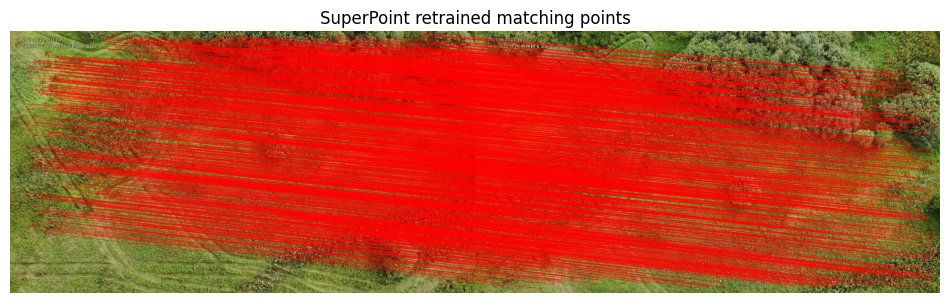

Затраченное время - 2.965083599090576 c.


In [21]:
sp_matching_points("dataset/big/frame_1501.jpg", "dataset/big/frame_1531.jpg")

## Оценка дообученной модели SuperPoint по метрике M_k

Оценим дообученную модель также по метрике $ M_5 $ при различных ограничениях максимального числа извлекаемых точек. Для этого на 200 изображениях (со смещением ~ 1 м между кадрами) для каждого окна из 5 кадров вычислим значение метрики, а затем найдём среднее по всем вычислениям.

In [5]:
def run_experiment_for_retrained(config_path, alpha, k=3, num_images=None):
    """Вычисляет среднее значение метрики М_k для дообученной модели SuperPoint

    Parameters
    ----------
    config_path : str
        путь до конфига с параметрами
    alpha : float
        коэффицент различающейся площади между кадрами
    k : int
        размер окна (по умолчанию 3)
    num_images : int, optional
        количество изображений для сравнения (по умолчанию будут взяты все)
    """
    retrained_sp = SuperPointRetrained(config_path)  # Инициализация модели
    all_frames = list(retrained_sp.data['test_loader'])

    retrained_sp_sum_all = []
    retrained_sp_av = []

    # Вычисление индекса для итерации по изображениям
    range_num = num_images - k + 1 if num_images else len(all_frames) - k + 1

    for i in range(range_num):
        # Извлечение ключевых точек и дескрипторов для первого изображения окна
        retrained_sp_kp0, retrained_sp_des0 = retrained_sp.detect_and_compute(all_frames[i])
        k_sum_retrained_sp = 0

        # Добавление количества извлеченных точек на изображении в список
        retrained_sp_av.append(len(retrained_sp_kp0))

        # Проход по окну
        for j in range(1, k):
            # Вычисление для j-ого кадра окна ключевых точек и дескрипторов
            retrained_sp_kp, retrained_sp_des = retrained_sp.detect_and_compute(all_frames[i+j])
            # Вычисление сопоставлений между первым и j-ым кадром окна
            retrained_sp_matches0j = retrained_sp.matches(retrained_sp_des0, retrained_sp_des)

            retrained_sp_matches, _, _ = retrained_sp.ratio_test(retrained_sp_matches0j, retrained_sp_kp0, retrained_sp_kp, ratio_index=retrained_sp.val_agent.nn_thresh)
            # Вычисление метрики М
            k_sum_retrained_sp += len(retrained_sp_matches) / (len(retrained_sp_kp) * (1 - alpha))

        # Усреднение метрики М на окне из k кадров
        retrained_sp_sum_all.append(k_sum_retrained_sp / (k - 1))

    # Вывод результатов
    retrained_sp_average = np.average(retrained_sp_sum_all)
    print("SuperPoint (retrained)")
    print("average:", retrained_sp_average)
    print("average num kps:", round(np.average(retrained_sp_av)))


In [ ]:
# MAX_NUM_POINTS = 10

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.28601562824722554
average num kps: 10


In [ ]:
# MAX_NUM_POINTS = 50

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.3188515732158444
average num kps: 50


In [ ]:
# MAX_NUM_POINTS = 100

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.3572078016542666
average num kps: 100


In [ ]:
# MAX_NUM_POINTS = 200

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.41080001246934617
average num kps: 200


In [ ]:
# MAX_NUM_POINTS = 500

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.48346512739515357
average num kps: 500


In [ ]:
# MAX_NUM_POINTS = 1000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.5373080240242737
average num kps: 1000


In [ ]:
# MAX_NUM_POINTS = 2000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.5854812648073486
average num kps: 2000


In [ ]:
# MAX_NUM_POINTS = 3000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.6103502500796653
average num kps: 3000


In [ ]:
# MAX_NUM_POINTS = 5000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.6368640633442786
average num kps: 5000


In [ ]:
# MAX_NUM_POINTS = 8000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.6461182283299963
average num kps: 7820


In [ ]:
# MAX_NUM_POINTS = 10000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.646874556140136
average num kps: 8439


Оценка показала, что после дообучения модель SuperPoint стала находить кратно больше ключевых признаков на изображениях лесистой местности.

Посмотрим на зависимость полученных результатов метрики $ M_5 $ от ограничения количества ключевых точек. Для этого добавим в файл [experiment.csv](experiment.csv) с результатами предыдущих сравнений новые полученные значения и построим графики для исходной модели SuperPoint и модели после дообучения.

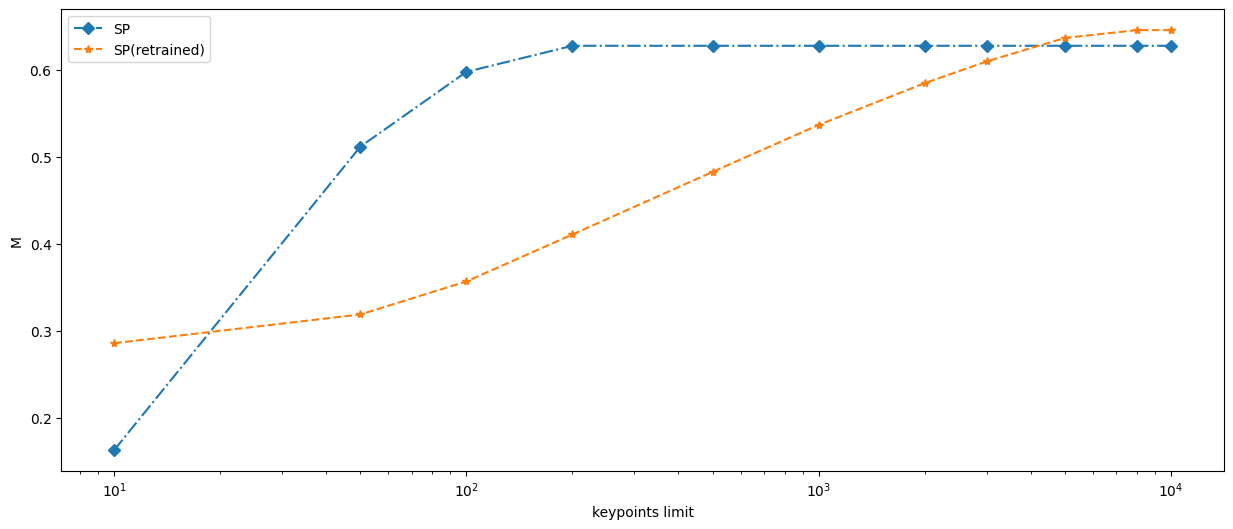

In [ ]:
import matplotlib.pyplot as plt
import csv

X = []  # Список для хранения ограничений по оси Х
data = []  # Список для хранения результатов для каждого метода

# Чтение данных из CSV файла с результатами эксперимента
with open('experiment.csv', 'r') as datafile:
    plotting = csv.reader(datafile, delimiter=';')

    # Считываем заголовки
    headers = next(plotting)

    # Инициализация списков для каждого столбца данных
    for _ in range(len(headers) - 1):
        data.append([])

    # Чтение данных и добавление в список
    for ROWS in plotting:
        X.append(float(ROWS[0]))
        for i in range(len(data)):
            data[i].append(float(ROWS[i + 1]))

# Стили линий и маркеров для графиков
styles = ['-', '--', '-.', '-.', ':', '--', '-', '--']
markers = ['P', 's', '^', 'D', 'v', 'x', 'o','*']

fig, ax = plt.subplots(1, 1, figsize=(15, 6))

# Построение графиков
for i in range(len(data)):
    if i == 3 or i == 7:
        plt.plot(X, data[i], marker=markers[i % len(markers)], linestyle=styles[i % len(styles)], label=headers[i + 1])

plt.xlabel('keypoints limit')
plt.ylabel('M')
plt.xscale('log')
plt.legend()
plt.show()

На данном графике можно заметить, что после тренировки удалось добиться повышения значения метрики отслеживаемости по сравнению с исходной моделью при извлечении больше 4000 ключевых точек, а также при совсем небольшом ограничении.

Результаты проведенного исследования подтверждают эффективность дообучения модели SuperPoint для задач навигации беспилотных летательных аппаратов в сложных условиях лесистой местности. Из этого можно сделать вывод, что полученная модель может быть успешно встроена в алгоритм навигации БПЛА для повышения его точности. Данная работа открывает новые перспективы для улучшения алгоритмов навигации, что, в свою очередь, может способствовать более безопасному и точному выполнению полетов БПЛА.